# Lab 2 · A 1D CNN on Real Clinical Spectra
**MSACL · DS301 Deep Learning · Segment 2 · Lab 2**

Last lab you built a network that reads a *table* of metabolite numbers. This lab, you'll
build one that reads a **spectrum** — the same 1D-CNN idea from Lecture 5, trained on real
**MALDI-TOF mass spectra** to call antimicrobial resistance straight from the instrument's
raw signal.

This is a ~45-minute session (+ 10 min discussion). **You fill in four short pieces**, all
about the new parts: the training loop reused on spectra, the CNN itself, and the batch size.
Everything else runs as-is.


## About the data: DRIAMS MALDI-TOF spectra

**DRIAMS** is a public database of routine clinical **MALDI-TOF mass spectra** paired with
antimicrobial-resistance lab results — the same kind of spectrum a clinical microbiology lab
already collects to identify a pathogen, here reused to predict whether it will respond to an
antibiotic *before* the days-long culture-based test comes back.

Today's task: **_Staphylococcus aureus_ + oxacillin** — the classic **MRSA** call. Each sample
is one spectrum, already reduced by the instrument's own processing pipeline to a fixed
**6,000-number vector** (intensity at each of 6,000 mass positions), with a label:

- **0 = susceptible** (oxacillin will likely work)
- **1 = resistant** (MRSA — a different antibiotic is needed)

> **Note:** this lab runs on a smaller *development slice* of DRIAMS (one hospital site,
> 738 spectra) — the full course dataset is larger and better balanced. The code here works
> identically either way; only the data file changes.


In [1]:
# Read and run — no need to edit.
import os
import urllib.request
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

torch.manual_seed(42)
np.random.seed(42)
print("Libraries ready.")


Libraries ready.


## Step 1 · Load the spectra *(runs for you)*

In [2]:
# Read and run — no need to edit.
# The data lives in this repo for local development; in Colab it downloads instead.
LOCAL_PATH = Path("../../data/slices/driams_c_saureus_oxacillin.npz")
RAW_URL = "https://raw.githubusercontent.com/<ORG>/<REPO>/main/data/slices/driams_c_saureus_oxacillin.npz"

if LOCAL_PATH.exists():
    npz_path = LOCAL_PATH
else:
    npz_path = Path("driams_c_saureus_oxacillin.npz")
    if not npz_path.exists():
        urllib.request.urlretrieve(RAW_URL, npz_path)

data = np.load(npz_path)
X = data["X"].astype("float32")   # shape (738, 6000): raw binned intensities
y = data["y"].astype("float32")   # 0 = susceptible, 1 = resistant

print("Spectra:", X.shape, "| resistant:", int(y.sum()), "/", len(y))


Spectra: (738, 6000) | resistant: 41 / 738


Here's what two real spectra look like — one susceptible, one resistant. Visually they're
very similar; the network's job is to find the subtle pattern a human eye can't easily spot.


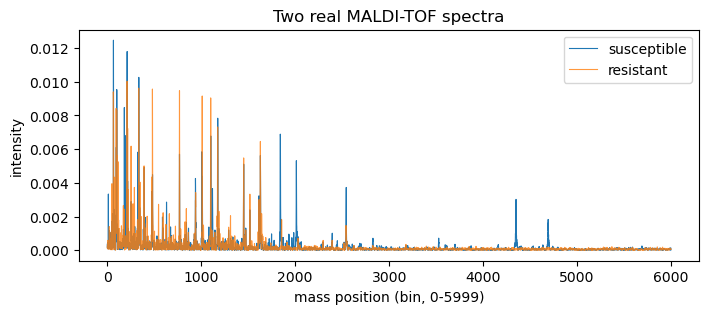

In [3]:
# Read and run — no need to edit.
sus_row = np.where(y == 0)[0][0]
res_row = np.where(y == 1)[0][0]

plt.figure(figsize=(8, 3))
plt.plot(X[sus_row], linewidth=0.8, label="susceptible")
plt.plot(X[res_row], linewidth=0.8, label="resistant", alpha=0.8)
plt.xlabel("mass position (bin, 0-5999)"); plt.ylabel("intensity")
plt.title("Two real MALDI-TOF spectra")
plt.legend()
plt.show()


## Step 2 · Split, balance-check, and normalize — by hand *(runs for you)*

Only **41 of 738** spectra are resistant (~5.6%) — a realistic clinical imbalance (MRSA is
the minority case). A plain shuffle-split could easily starve the test set of resistant
examples entirely, so we split **within each class separately**, then combine — this is
called a **stratified split**, and it guarantees both the train and test sets contain
resistant examples.

We also **normalize each spectrum by its own peak intensity** — instrument runs vary in
overall signal strength, so this puts every spectrum on the same 0–1 scale before training.


In [4]:
# Read and run — no need to edit.
# --- stratified 80/20 split: split resistant and susceptible indices separately ---
pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]
np.random.shuffle(pos_idx)
np.random.shuffle(neg_idx)

n_pos_train = int(0.8 * len(pos_idx))
n_neg_train = int(0.8 * len(neg_idx))

train_idx = np.concatenate([pos_idx[:n_pos_train], neg_idx[:n_neg_train]])
test_idx = np.concatenate([pos_idx[n_pos_train:], neg_idx[n_neg_train:]])
np.random.shuffle(train_idx)   # mix classes together within the split
np.random.shuffle(test_idx)

# --- normalize: divide each spectrum by its own maximum intensity ---
X_norm = X / X.max(axis=1, keepdims=True)

X_train, y_train = X_norm[train_idx], y[train_idx]
X_test, y_test = X_norm[test_idx], y[test_idx]

print(f"train: {len(train_idx)} spectra ({int(y_train.sum())} resistant)")
print(f"test:  {len(test_idx)} spectra ({int(y_test.sum())} resistant)")

# tensors: add a "channel" dimension of size 1 for Conv1d -> shape (N, 1, 6000)
X_train_t = torch.tensor(X_train).unsqueeze(1)
X_test_t = torch.tensor(X_test).unsqueeze(1)
y_train_t = torch.tensor(y_train).unsqueeze(1)
y_test_t = torch.tensor(y_test).unsqueeze(1)

n_pos, n_neg = int(y_train.sum()), int(len(y_train) - y_train.sum())
print(f"class imbalance: {n_pos} resistant vs {n_neg} susceptible "
      f"({100 * n_pos / len(y_train):.1f}% resistant) — the rare-class problem of Lecture 10")


train: 589 spectra (32 resistant)
test:  149 spectra (9 resistant)
class imbalance: 32 resistant vs 557 susceptible (5.4% resistant) — the rare-class problem of Lecture 10


## Step 3 · The training loop — YOUR TURN ✏️

This is the **exact same recipe** from Lecture 2 / Lab 1 — forward, loss, zero, backward,
step — reused here for spectra, in **mini-batches** (train on a handful of spectra at a
time, many times per epoch, rather than all 590 at once). We wrap it in a function so we
can reuse it for the different comparisons below, with a **live progress bar** showing the
loss as it trains.

**Fill in the five lines** inside the batch loop, in order (same names as Lab 1):


In [5]:
def train_model(model, X, y, epochs, batch_size, lr, loss_fn):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    n = X.shape[0]
    loss_history = []

    pbar = tqdm(range(epochs), desc="training")
    for epoch in pbar:
        order = torch.randperm(n)                       # shuffle sample order each epoch
        epoch_loss = 0.0
        for start in range(0, n, batch_size):
            batch_idx = order[start:start + batch_size]
            X_batch, y_batch = X[batch_idx], y[batch_idx]

            ### BEGIN SOLUTION
            pred = model(X_batch)                        # 1. forward  — make a guess
            loss = loss_fn(pred, y_batch)                # 2. loss     — how wrong?
            optimizer.zero_grad()                        # 3. zero     — clear old gradients
            loss.backward()                              # 4. backward — backprop the blame
            optimizer.step()                              # 5. step     — nudge every weight
            ### END SOLUTION

            epoch_loss += loss.item() * len(batch_idx)
        avg_loss = epoch_loss / n
        loss_history.append(avg_loss)
        pbar.set_postfix(loss=f"{avg_loss:.3f}")          # live loss monitor on the progress bar
    return loss_history

# --- self-check: do not edit ---
_probe_model = nn.Linear(4, 1)
_probe_X = torch.randn(20, 4)
_probe_y = torch.randint(0, 2, (20, 1)).float()
_probe_history = train_model(_probe_model, _probe_X, _probe_y, epochs=2, batch_size=5,
                              lr=0.01, loss_fn=nn.BCEWithLogitsLoss())
assert len(_probe_history) == 2, f"expected 2 loss values (one per epoch), got {len(_probe_history)}"
assert all(isinstance(v, float) for v in _probe_history), "loss_history should hold plain floats"
print("Loop checks out — 2 epochs ran, loss history:", [round(v, 3) for v in _probe_history])


training:   0%|          | 0/2 [00:00<?, ?it/s]

Loop checks out — 2 epochs ran, loss history: [0.693, 0.679]


In [6]:
# Read and run — no need to edit.
def evaluate_model(model, X, y, threshold=0.5):
    with torch.no_grad():
        probs = torch.sigmoid(model(X))
    predicted = (probs > threshold).float()               # call 'resistant' when prob clears the threshold
    accuracy = (predicted == y).float().mean().item()
    # resistant recall: of the truly-resistant cases, how many did we catch?
    is_resistant = (y == 1)
    if is_resistant.sum() > 0:
        recall = (predicted[is_resistant] == 1).float().mean().item()
    else:
        recall = float("nan")
    return accuracy, recall

print("Evaluation helper ready.")


Evaluation helper ready.


## Step 4 · Build the 1D CNN — YOUR TURN ✏️

A CNN doesn't need every position wired to every neuron — it slides a small **filter** along
the m/z axis, the same "peak detector everywhere" idea from Lecture 5. Fill in **two** conv
blocks:

**Blank 1 — the first `Conv1d`.** Use exactly the arguments from the Lecture 5 code slide:
one input channel (a raw spectrum), 8 filters, a filter that's 15 bins wide, and padding so
the output stays the same length.

**Blank 2 — a second conv block.** Mirror block 1's pattern (`Conv1d` → `ReLU` → `MaxPool1d`),
but now reading the **8** channels block 1 produced and turning them into **16**.


In [7]:
class SpectrumCNN(nn.Module):
    def __init__(self):
        super().__init__()

        ### BEGIN SOLUTION
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=8, kernel_size=15, padding=7)
        ### END SOLUTION
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(4)     # 6000 -> 1500

        ### BEGIN SOLUTION
        self.conv2 = nn.Conv1d(in_channels=8, out_channels=16, kernel_size=15, padding=7)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(4)     # 1500 -> 375
        ### END SOLUTION

        self.flatten = nn.Flatten()               # (N, 16, 375) -> (N, 6000)
        self.fc1 = nn.Linear(16 * 375, 32)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        return self.fc2(x)

# --- self-checks: do not edit ---
_probe = SpectrumCNN()
_out1 = _probe.pool1(_probe.relu1(_probe.conv1(torch.zeros(2, 1, 6000))))
assert _out1.shape == (2, 8, 1500), f"expected (2, 8, 1500) after block 1, got {tuple(_out1.shape)}"
_out2 = _probe.pool2(_probe.relu2(_probe.conv2(_out1)))
assert _out2.shape == (2, 16, 375), f"expected (2, 16, 375) after block 2, got {tuple(_out2.shape)}"
print("Shapes check out — block 1:", tuple(_out1.shape), "→ block 2:", tuple(_out2.shape))


Shapes check out — block 1: (2, 8, 1500) → block 2: (2, 16, 375)


## Step 5 · Choose a batch size — YOUR TURN ✏️

Bigger batches give a smoother, more confident gradient but fewer updates per epoch (and can
generalize *worse*, from Lecture 4); tiny batches are noisy but update often. Pick a
reasonable **middle-ground** batch size for 590 training spectra.


In [8]:
### BEGIN SOLUTION
CNN_BATCH_SIZE = 32
### END SOLUTION

# --- self-check: do not edit ---
assert 4 <= CNN_BATCH_SIZE <= 128, "pick a batch size between 4 and 128 - see Lecture 4's Goldilocks range"
print("Using batch size:", CNN_BATCH_SIZE)


Using batch size: 32


## Step 6 · Train the CNN *(runs for you)*

Watch the progress bar's loss shrink as it trains.


training:   0%|          | 0/10 [00:00<?, ?it/s]

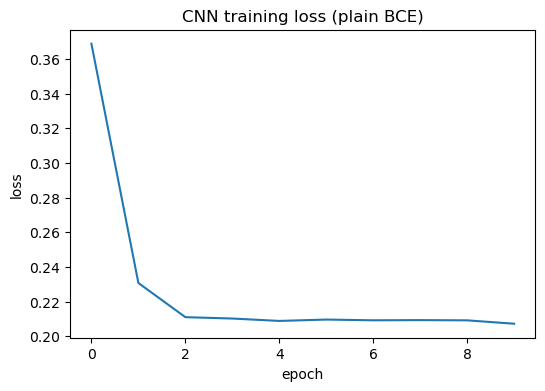

CNN @ threshold 0.5  ->  test accuracy: 0.94   resistant recall: 0.00


In [9]:
# Read and run — no need to edit.
loss_fn = nn.BCEWithLogitsLoss()          # plain binary cross-entropy — every spectrum weighted equally

cnn = SpectrumCNN()
cnn_losses = train_model(cnn, X_train_t, y_train_t, epochs=10, batch_size=CNN_BATCH_SIZE,
                          lr=0.001, loss_fn=loss_fn)
cnn_acc, cnn_recall = evaluate_model(cnn, X_test_t, y_test_t)   # uses the default 0.5 threshold

plt.figure(figsize=(6, 4))
plt.plot(cnn_losses)
plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("CNN training loss (plain BCE)")
plt.show()

print(f"CNN @ threshold 0.5  ->  test accuracy: {cnn_acc:.2f}   resistant recall: {cnn_recall:.2f}")


**Read the recall number, not just accuracy.** With ~94% of spectra susceptible, a lazy
model that always guesses "susceptible" already scores ~94% accuracy while catching **zero**
resistant cases — exactly the trap Lecture 10 warns about. And that's very nearly what plain
BCE does here: trained on 17-to-1 imbalanced data, it learns to output a *low* probability for
almost every spectrum, so at the **default 0.5 threshold** it flags hardly any resistant cases
and recall looks terrible.

But don't write the model off yet — that dismal recall is an artifact of *where we drew the
line*, not proof the model learned nothing. The next step shows why.


## Step 7 · Recall depends on the threshold *(runs for you)*

The model doesn't output "resistant" or "susceptible" — it outputs a **probability**. We call a
spectrum resistant when that probability clears a **threshold**, and `0.5` is just a default,
not a law of nature. On 17-to-1 imbalanced data the model's probabilities pile up *low*, so
`0.5` sits above almost all of them — a terrible place to draw the line.

Let's **sweep the threshold** and watch what happens to recall. The same `evaluate_model` helper
takes a `threshold` argument — we just feed it different cuts.


In [10]:
# Read and run — no need to edit.
with torch.no_grad():
    probs = torch.sigmoid(cnn(X_test_t)).numpy().ravel()   # the model's raw probabilities on the test set
truth = y_test_t.numpy().ravel()

# a ladder of thresholds: the default 0.5, plus a few drawn from the model's own output range
ladder = np.quantile(probs, [0.95, 0.90, 0.80, 0.50])
thresholds = sorted(set(np.round(np.append(ladder, 0.5), 3)), reverse=True)

print(f"{'threshold':>10} {'recall':>8} {'precision':>10} {'accuracy':>9}")
for t in thresholds:
    accuracy, recall = evaluate_model(cnn, X_test_t, y_test_t, threshold=t)   # same helper, new cut
    flagged = probs > t
    precision = f"{(truth[flagged] == 1).mean():.2f}" if flagged.sum() > 0 else "  —"
    print(f"{t:>10.3f} {recall:>8.2f} {precision:>10} {accuracy:>9.2f}")


 threshold   recall  precision  accuracy
     0.500     0.00          —      0.94
     0.075     0.22       0.25      0.91
     0.070     0.33       0.19      0.87
     0.064     0.44       0.14      0.80
     0.050     0.67       0.08      0.53


Read the table top to bottom. At **0.5** the model catches almost no resistant cases (recall ≈ 0)
while accuracy sits near 0.94 — the "always susceptible" trap. But drop the threshold and **recall
climbs**: the model *did* learn a usable signal, we were just slicing it in the wrong place. The
price is precision and accuracy — lower cuts flag more false alarms.

There is no free lunch and no universal "right" threshold: it's a **clinical decision**. For an MRSA
screen you'd tolerate false alarms to avoid missing a resistant case, so you'd pick the threshold on
a validation set to hit a required recall — never blindly trust 0.5. This is the imbalanced-data
lesson of Lecture 10.


## What just happened

You adapted the Lab 1 recipe to a real clinical signal:
- the **same five-line training loop**, now wrapped for **mini-batches** with a live progress bar,
- a **1D CNN** that slides filters along the m/z axis instead of flattening everything,
- an honest look at **imbalanced classification** — accuracy alone would have hidden a model
  that never catches a single resistant case,
- and the key idea that **recall depends on the decision threshold**: 0.5 is an arbitrary default,
  and on rare-class data you choose the cut to hit a clinical target, not the other way around.

With only 738 spectra from one site, don't expect huge numbers — the point is the *shape* of
the recipe, which is identical on the full production dataset.


## Optional stretch: a loss built for rare cases — focal loss *(only if you're ahead)*

Instead of moving the threshold *after* training, can we train a model whose probabilities aren't so
squashed toward zero? **Focal loss** (Lecture 4) does two things: it **down-weights** examples the
model already gets right confidently (so training concentrates on the hard, easy-to-miss cases), and
its `alpha` term **tilts the balance toward the rare resistant class**. The result: more resistant
spectra push their probability up past 0.5 on their own. Train it and compare recall at the *same*
default 0.5 cut.


In [11]:
# Optional - read and run, or tweak alpha / gamma yourself.
def focal_loss(logits, targets, alpha=0.946, gamma=2.0):
    p = torch.sigmoid(logits)
    ce = torch.nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    focal_w = (targets - p).abs().pow(gamma)                 # shrinks toward 0 for easy/confident cases
    alpha_t = targets * alpha + (1 - targets) * (1 - alpha)  # tilts the balance toward the rare resistant class
    return (alpha_t * focal_w * ce).mean()

cnn_focal = SpectrumCNN()
focal_losses = train_model(cnn_focal, X_train_t, y_train_t, epochs=10, batch_size=CNN_BATCH_SIZE,
                            lr=0.001, loss_fn=focal_loss)
focal_acc, focal_recall = evaluate_model(cnn_focal, X_test_t, y_test_t)   # same default 0.5 threshold

print(f"plain BCE   @ 0.5  ->  accuracy: {cnn_acc:.2f}   recall: {cnn_recall:.2f}")
print(f"focal loss  @ 0.5  ->  accuracy: {focal_acc:.2f}   recall: {focal_recall:.2f}")


training:   0%|          | 0/10 [00:00<?, ?it/s]

plain BCE   @ 0.5  ->  accuracy: 0.94   recall: 0.00
focal loss  @ 0.5  ->  accuracy: 0.30   recall: 0.89


## Discussion (10 min)

**Where in your workflow is there a 1D signal a CNN could read? Who labels it today, and how
well?** Think of a chromatogram, a QC trace, or another spectrum you see routinely — and how
confident a human currently is when reading it.
